In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

# 데이터 불러오기
df = pd.read_csv("project_data_B.csv")

# 기본 확인
print("데이터 크기:", df.shape)
display(df.head())

print("\n컬럼 정보")
print(df.columns.tolist())

print("\n결측치")
print(df.isnull().sum())

print("\nMachine failure 분포")
print(df["Machine failure"].value_counts())
print(df["Machine failure"].value_counts(normalize=True))

데이터 크기: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0



컬럼 정보
['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

결측치
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

Machine failure 분포
Machine failure
0    9661
1     339
Name: count, dtype: int64
Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64


In [2]:
# -----------------------------
# 2. 데이터 기본 전처리 확인
# -----------------------------

failure_cols = ["TWF", "HDF", "PWF", "OSF", "RNF"]

# 중복 데이터 확인
print("전체 중복 행:", df.duplicated().sum())

# 제품 Type 분포
print("\nType 분포")
print(df["Type"].value_counts())

# 고장 유형별 발생 건수
print("\n고장 유형별 발생 건수")
print(df[failure_cols].sum().sort_values(ascending=False))

# 한 행에서 동시에 발생한 고장 유형 개수
df["Failure_count"] = df[failure_cols].sum(axis=1)

print("\n동시 고장 유형 개수 분포")
print(df["Failure_count"].value_counts().sort_index())

# Machine failure과 개별 고장 라벨의 관계 확인
print("\nMachine failure=1 중 고장 유형 표시 개수")
print(df.loc[df["Machine failure"] == 1, "Failure_count"].value_counts().sort_index())

# 분석에서 식별자 컬럼 제거
data = df.drop(columns=["UDI", "Product ID"]).copy()

print("\n분석용 데이터 크기:", data.shape)
display(data.head())

전체 중복 행: 0

Type 분포
Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

고장 유형별 발생 건수
HDF    115
OSF     98
PWF     95
TWF     46
RNF     19
dtype: int64

동시 고장 유형 개수 분포
Failure_count
0    9652
1     324
2      23
3       1
Name: count, dtype: int64

Machine failure=1 중 고장 유형 표시 개수
Failure_count
0      9
1    306
2     23
3      1
Name: count, dtype: int64

분석용 데이터 크기: (10000, 13)


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Failure_count
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,0


In [3]:
# -----------------------------
# 3. Machine failure과 고장 유형 라벨 관계 확인
# -----------------------------

# Machine failure = 0인데 고장 유형이 표시된 경우
case_a = df[
    (df["Machine failure"] == 0) &
    (df["Failure_count"] > 0)
]

# Machine failure = 1인데 고장 유형이 하나도 없는 경우
case_b = df[
    (df["Machine failure"] == 1) &
    (df["Failure_count"] == 0)
]

print("Machine failure=0인데 고장유형 존재:", len(case_a))
print(case_a[failure_cols].sum())

print("\nMachine failure=1인데 고장유형 없음:", len(case_b))

display(case_a[
    ["UDI", "Machine failure", "TWF", "HDF", "PWF", "OSF", "RNF"]
].head(20))

display(case_b[
    ["UDI", "Machine failure", "TWF", "HDF", "PWF", "OSF", "RNF"]
].head(20))

Machine failure=0인데 고장유형 존재: 18
TWF     0
HDF     0
PWF     0
OSF     0
RNF    18
dtype: int64

Machine failure=1인데 고장유형 없음: 9


,UDI,Machine failure,TWF,HDF,PWF,OSF,RNF
1221,1222,0,0,0,0,0,1
1302,1303,0,0,0,0,0,1
1748,1749,0,0,0,0,0,1
2072,2073,0,0,0,0,0,1
2559,2560,0,0,0,0,0,1
3065,3066,0,0,0,0,0,1
3452,3453,0,0,0,0,0,1
5471,5472,0,0,0,0,0,1
5489,5490,0,0,0,0,0,1
5495,5496,0,0,0,0,0,1


,UDI,Machine failure,TWF,HDF,PWF,OSF,RNF
1437,1438,1,0,0,0,0,0
2749,2750,1,0,0,0,0,0
4044,4045,1,0,0,0,0,0
4684,4685,1,0,0,0,0,0
5536,5537,1,0,0,0,0,0
5941,5942,1,0,0,0,0,0
6478,6479,1,0,0,0,0,0
8506,8507,1,0,0,0,0,0
9015,9016,1,0,0,0,0,0


In [4]:
# -----------------------------
# 4. Feature Engineering
# -----------------------------

data = df.copy()

# 식별자 제거
data = data.drop(columns=["Product ID"])

# 범주형 변수 One-Hot Encoding
data = pd.get_dummies(data, columns=["Type"], drop_first=True)

# -----------------------------
# 1) 물리 기반 파생변수
# -----------------------------

# 공정 온도 - 공기 온도
data["Temp_Diff"] = (
    data["Process temperature [K]"]
    - data["Air temperature [K]"]
)

# 기계적 동력: P = Torque × omega
data["Mechanical_Power"] = (
    data["Torque [Nm]"]
    * (2 * np.pi * data["Rotational speed [rpm]"] / 60)
)

# 공구 마모와 부하를 함께 고려한 지표
data["Wear_Torque"] = (
    data["Tool wear [min]"]
    * data["Torque [Nm]"]
)

# -----------------------------
# 2) 시계열 파생변수
# -----------------------------

window = 10

# 이동평균
data["Torque_MA"] = (
    data["Torque [Nm]"]
    .rolling(window=window)
    .mean()
)

# 이동표준편차
data["Torque_STD"] = (
    data["Torque [Nm]"]
    .rolling(window=window)
    .std()
)

# 변화량
data["RPM_Diff"] = (
    data["Rotational speed [rpm]"]
    .diff()
)

# Rolling / Diff 때문에 생긴 초기 NaN 제거
data = data.dropna().reset_index(drop=True)

# -----------------------------
# 결과 확인
# -----------------------------

new_features = [
    "Temp_Diff",
    "Mechanical_Power",
    "Wear_Torque",
    "Torque_MA",
    "Torque_STD",
    "RPM_Diff"
]

print("Feature Engineering 완료")
print("데이터 크기:", data.shape)

display(data[new_features].head())

print("\n파생변수 기초통계")
display(data[new_features].describe())

Feature Engineering 완료
데이터 크기: (9991, 21)


,Temp_Diff,Mechanical_Power,Wear_Torque,Torque_MA,Torque_STD,RPM_Diff
0,10.5,5104.878623,588.0,39.91,6.826655,74.0
1,10.5,4459.993427,573.6,38.02,8.377722,41.0
2,10.5,6601.418171,1284.7,37.82,8.179622,-359.0
3,10.5,7165.229333,1737.4,37.99,8.459899,-84.0
4,10.6,5472.654403,1110.0,37.04,8.798131,403.0



파생변수 기초통계


,Temp_Diff,Mechanical_Power,Wear_Torque,Torque_MA,Torque_STD,RPM_Diff
count,9991.000000,9991.000000,9991.000000,9991.000000,9991.000000,9991.000000
mean,10.000210,6279.602177,4318.227465,39.986677,9.678622,-0.016715
std,1.001446,1067.652126,2825.338855,3.177969,2.360219,252.671337
min,7.600000,1148.440610,0.000000,28.430000,2.925064,-1478.000000
25%,9.300000,5561.027404,1969.750000,37.810000,7.989785,-133.000000
50%,9.800000,6270.828376,4015.000000,40.020000,9.563362,-1.000000
75%,11.000000,7003.065556,6281.050000,42.170000,11.209463,134.000000
max,12.100000,10469.923005,16497.000000,50.960000,19.519680,1449.000000


In [5]:
# -----------------------------
# 5. Train / Test 분할
# -----------------------------

# Target
target = "Machine failure"

# 모델 입력에서 제외할 컬럼
drop_cols = [
    "Machine failure",
    "TWF", "HDF", "PWF", "OSF", "RNF",
    "Failure_count",
    "UDI"
]

X = data.drop(columns=drop_cols)
y = data[target]

# 앞 80% Train / 뒤 20% Test
split_idx = int(len(data) * 0.8)

X_train = X.iloc[:split_idx].copy()
X_test  = X.iloc[split_idx:].copy()

y_train = y.iloc[:split_idx].copy()
y_test  = y.iloc[split_idx:].copy()

print("전체 데이터:", len(data))
print("Train:", len(X_train))
print("Test :", len(X_test))

print("\nTrain 고장 분포")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

print("\nTest 고장 분포")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True))

print("\n최종 Feature 수:", X_train.shape[1])
print(X_train.columns.tolist())

전체 데이터: 9991
Train: 7992
Test : 1999

Train 고장 분포
Machine failure
0    7692
1     300
Name: count, dtype: int64
Machine failure
0    0.962462
1    0.037538
Name: proportion, dtype: float64

Test 고장 분포
Machine failure
0    1960
1      39
Name: count, dtype: int64
Machine failure
0    0.98049
1    0.01951
Name: proportion, dtype: float64

최종 Feature 수: 13
['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type_L', 'Type_M', 'Temp_Diff', 'Mechanical_Power', 'Wear_Torque', 'Torque_MA', 'Torque_STD', 'RPM_Diff']


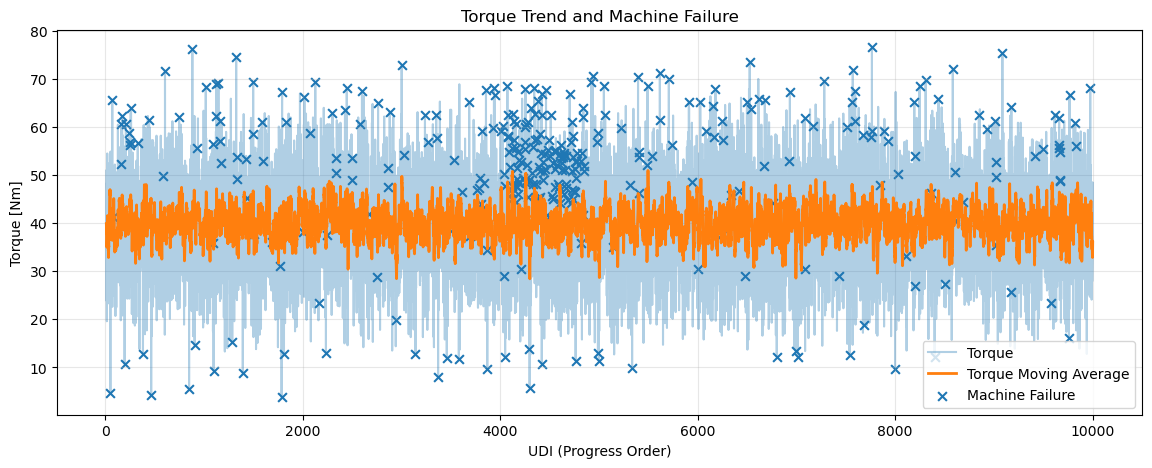

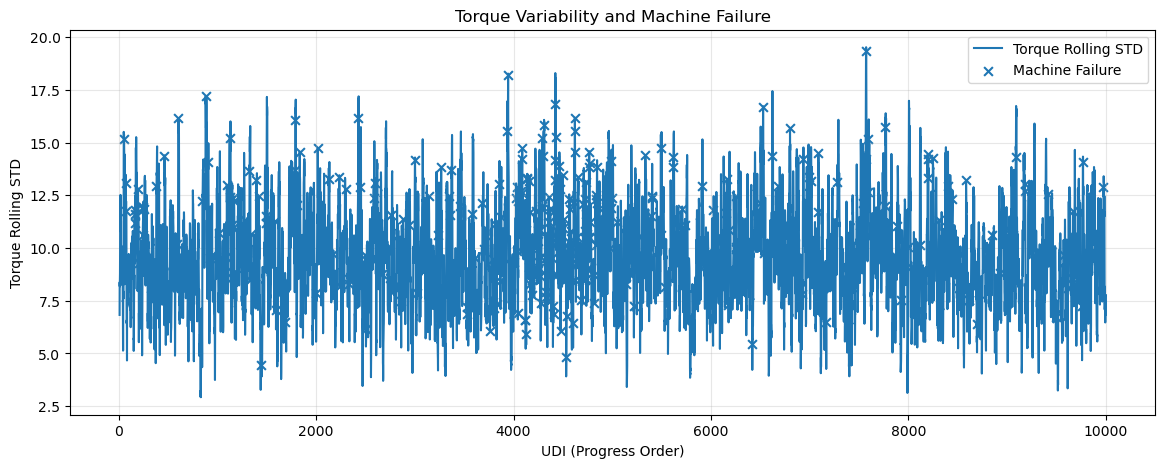

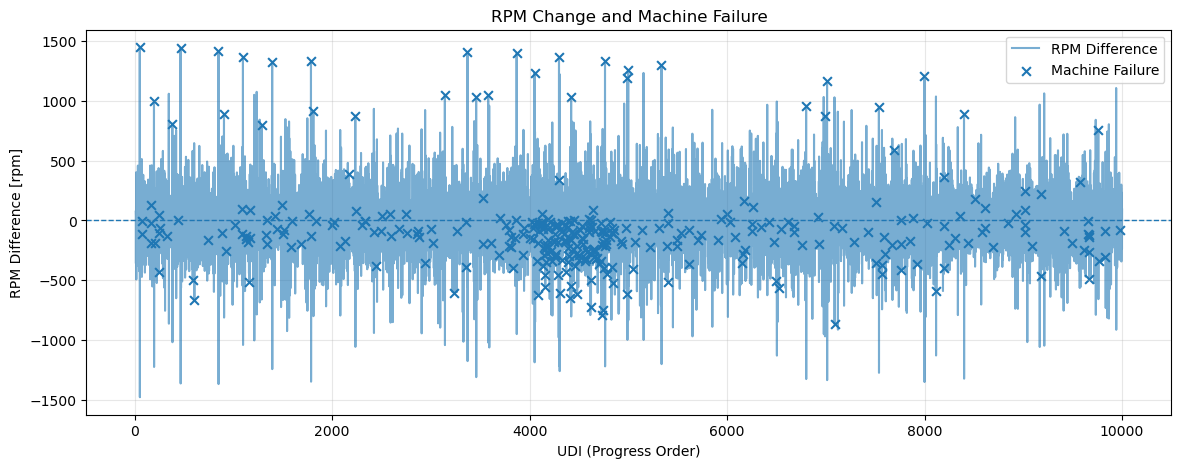

In [6]:
# -----------------------------
# 6. 시계열 특성 시각화
# -----------------------------

# 고장 발생 지점
failure_data = data[data["Machine failure"] == 1]

# 1) Torque + Moving Average
plt.figure(figsize=(14, 5))

plt.plot(
    data["UDI"],
    data["Torque [Nm]"],
    alpha=0.35,
    label="Torque"
)

plt.plot(
    data["UDI"],
    data["Torque_MA"],
    linewidth=2,
    label="Torque Moving Average"
)

plt.scatter(
    failure_data["UDI"],
    failure_data["Torque [Nm]"],
    marker="x",
    s=40,
    label="Machine Failure"
)

plt.xlabel("UDI (Progress Order)")
plt.ylabel("Torque [Nm]")
plt.title("Torque Trend and Machine Failure")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# 2) Torque 변동성
plt.figure(figsize=(14, 5))

plt.plot(
    data["UDI"],
    data["Torque_STD"],
    label="Torque Rolling STD"
)

plt.scatter(
    failure_data["UDI"],
    failure_data["Torque_STD"],
    marker="x",
    s=40,
    label="Machine Failure"
)

plt.xlabel("UDI (Progress Order)")
plt.ylabel("Torque Rolling STD")
plt.title("Torque Variability and Machine Failure")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# 3) RPM 변화량
plt.figure(figsize=(14, 5))

plt.plot(
    data["UDI"],
    data["RPM_Diff"],
    alpha=0.6,
    label="RPM Difference"
)

plt.scatter(
    failure_data["UDI"],
    failure_data["RPM_Diff"],
    marker="x",
    s=40,
    label="Machine Failure"
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.xlabel("UDI (Progress Order)")
plt.ylabel("RPM Difference [rpm]")
plt.title("RPM Change and Machine Failure")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

=== Z-score Baseline ===
Precision : 0.196
Recall    : 0.231
F1-score  : 0.212

예측 분포
0    1953
1      46
Name: count, dtype: int64

Confusion Matrix
[[1923   37]
 [  30    9]]


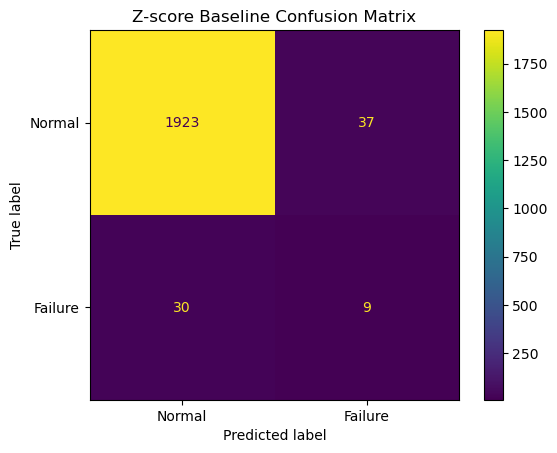

In [7]:
# -----------------------------
# 7. Z-score Baseline
# -----------------------------

# Z-score를 계산할 연속형 변수
z_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Temp_Diff",
    "Mechanical_Power",
    "Wear_Torque",
    "Torque_MA",
    "Torque_STD",
    "RPM_Diff"
]

# Train 데이터로 평균 / 표준편차 계산
train_mean = X_train[z_features].mean()
train_std = X_train[z_features].std()

# Test 데이터의 Z-score 계산
z_test = (
    (X_test[z_features] - train_mean)
    / train_std
).abs()

# 하나의 변수라도 |Z| > 3이면 고장(1)으로 판정
z_pred = (z_test > 3).any(axis=1).astype(int)

# 성능 평가
z_precision = precision_score(y_test, z_pred, zero_division=0)
z_recall = recall_score(y_test, z_pred, zero_division=0)
z_f1 = f1_score(y_test, z_pred, zero_division=0)

print("=== Z-score Baseline ===")
print(f"Precision : {z_precision:.3f}")
print(f"Recall    : {z_recall:.3f}")
print(f"F1-score  : {z_f1:.3f}")

print("\n예측 분포")
print(pd.Series(z_pred).value_counts())

print("\nConfusion Matrix")
cm_z = confusion_matrix(y_test, z_pred)
print(cm_z)

# 혼동행렬 시각화
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=cm_z,
    display_labels=["Normal", "Failure"]
).plot()

plt.title("Z-score Baseline Confusion Matrix")
plt.show()

In [8]:
# -----------------------------
# 8. Machine Learning Model 비교
# -----------------------------

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# -----------------------------
# 1) Logistic Regression
# -----------------------------

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

log_pred = logistic_model.predict(X_test)

# -----------------------------
# 2) Random Forest
# -----------------------------

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

# -----------------------------
# 모델별 성능 계산
# -----------------------------

results = pd.DataFrame({
    "Model": [
        "Z-score Baseline",
        "Logistic Regression",
        "Random Forest"
    ],
    "Precision": [
        z_precision,
        precision_score(y_test, log_pred, zero_division=0),
        precision_score(y_test, rf_pred, zero_division=0)
    ],
    "Recall": [
        z_recall,
        recall_score(y_test, log_pred, zero_division=0),
        recall_score(y_test, rf_pred, zero_division=0)
    ],
    "F1-score": [
        z_f1,
        f1_score(y_test, log_pred, zero_division=0),
        f1_score(y_test, rf_pred, zero_division=0)
    ]
})

display(results.round(3))


# 혼동행렬 출력
print("=== Logistic Regression ===")
print(confusion_matrix(y_test, log_pred))

print("\n=== Random Forest ===")
print(confusion_matrix(y_test, rf_pred))

,Model,Precision,Recall,F1-score
0,Z-score Baseline,0.196,0.231,0.212
1,Logistic Regression,0.205,0.641,0.311
2,Random Forest,1.000,0.615,0.762


=== Logistic Regression ===
[[1863   97]
 [  14   25]]

=== Random Forest ===
[[1960    0]
 [  15   24]]


,Metric,Score
0,Precision,1.000
1,Recall,0.615
2,F1-score,0.762


=== Classification Report ===
              precision    recall  f1-score   support

      Normal      0.992     1.000     0.996      1960
     Failure      1.000     0.615     0.762        39

    accuracy                          0.992      1999
   macro avg      0.996     0.808     0.879      1999
weighted avg      0.993     0.992     0.992      1999



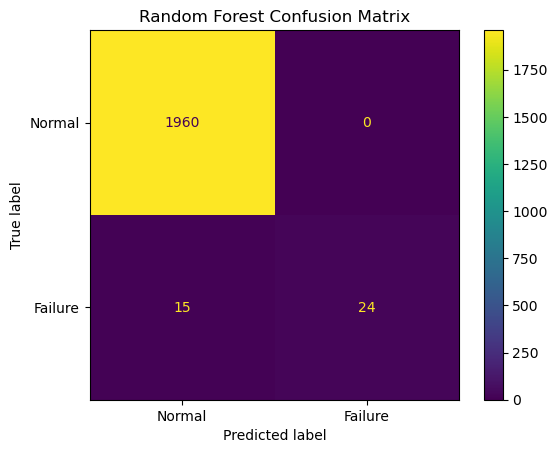

In [9]:
# -----------------------------
# 9. Final Model Evaluation
# -----------------------------

from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay
)

# 최종 모델: Random Forest
final_model = rf_model
final_pred = rf_pred

# 성능 지표
final_precision = precision_score(y_test, final_pred, zero_division=0)
final_recall = recall_score(y_test, final_pred, zero_division=0)
final_f1 = f1_score(y_test, final_pred, zero_division=0)

# 최종 평가표
final_result = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1-score"],
    "Score": [
        final_precision,
        final_recall,
        final_f1
    ]
})

display(final_result.round(3))

# Classification Report
print("=== Classification Report ===")
print(
    classification_report(
        y_test,
        final_pred,
        target_names=["Normal", "Failure"],
        digits=3
    )
)

# Confusion Matrix
cm_final = confusion_matrix(y_test, final_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_final,
    display_labels=["Normal", "Failure"]
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [10]:
# -----------------------------
# 10. 오탐 / 미탐 사례 분석
# -----------------------------

# Test 데이터 원본 인덱스 맞추기
test_data = data.iloc[split_idx:].copy()

test_data["Actual"] = y_test.values
test_data["Predicted"] = final_pred

# False Positive
fp_data = test_data[
    (test_data["Actual"] == 0) &
    (test_data["Predicted"] == 1)
]

# False Negative
fn_data = test_data[
    (test_data["Actual"] == 1) &
    (test_data["Predicted"] == 0)
]

print("False Positive 개수:", len(fp_data))
print("False Negative 개수:", len(fn_data))

# 미탐 사례 주요 변수 확인
analysis_cols = [
    "UDI",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Temp_Diff",
    "Mechanical_Power",
    "Wear_Torque",
    "Torque_MA",
    "Torque_STD",
    "RPM_Diff",
    "TWF", "HDF", "PWF", "OSF"
]

print("\n=== False Negative 사례 ===")
display(fn_data[analysis_cols].head(15))

print("\n=== 실제 탐지된 고장 사례 ===")
tp_data = test_data[
    (test_data["Actual"] == 1) &
    (test_data["Predicted"] == 1)
]

display(tp_data[analysis_cols].head(15))

False Positive 개수: 0
False Negative 개수: 15

=== False Negative 사례 ===


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temp_Diff,Mechanical_Power,Wear_Torque,Torque_MA,Torque_STD,RPM_Diff,TWF,HDF,PWF,OSF
8017,8027,300.7,311.9,1399,50.2,222,11.2,7354.447458,11144.4,38.21,9.096452,-23.0,0,0,0,1
8102,8112,300.4,311.8,1553,33.1,209,11.4,5383.045708,6917.9,35.88,10.149745,-588.0,1,0,0,0
8190,8200,299.2,310.7,1737,27.0,225,11.5,4911.251795,6075.0,40.93,13.328837,363.0,1,0,0,0
8348,8358,298.5,309.5,1385,46.3,203,11.0,6715.206657,9398.9,44.58,10.080432,41.0,1,0,0,0
8497,8507,298.4,309.6,1710,27.3,163,11.2,4888.632328,4449.9,37.11,8.115890,180.0,0,0,0,0
8600,8610,297.4,308.3,1475,40.5,222,10.9,6255.696371,8991.0,43.17,7.532603,106.0,1,0,0,0
8681,8691,297.1,308.5,1323,44.4,207,11.4,6151.364079,9190.8,40.36,6.404720,-220.0,1,0,0,0
8917,8927,297.3,308.3,1459,59.6,207,11.0,9106.052914,12337.2,42.84,8.830654,54.0,0,0,1,1
9006,9016,297.2,308.1,1431,49.7,210,10.9,7447.742288,10437.0,42.07,9.460685,91.0,0,0,0,0
9009,9019,297.3,308.1,1615,35.4,217,10.8,5986.933120,7681.8,43.04,10.723722,246.0,1,0,0,0



=== 실제 탐지된 고장 사례 ===


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temp_Diff,Mechanical_Power,Wear_Torque,Torque_MA,Torque_STD,RPM_Diff,TWF,HDF,PWF,OSF
8183,8193,299.6,310.9,1229,65.2,209,11.3,8391.277754,13626.8,36.97,14.228223,-401.0,0,0,0,1
8186,8196,299.4,310.8,1376,53.9,215,11.4,7766.687246,11588.5,38.56,14.454772,-50.0,0,0,0,1
8236,8246,299.0,310.3,1303,68.6,111,11.3,9360.459087,7614.6,41.51,14.269817,-209.0,0,0,1,0
8298,8308,298.7,310.1,1402,69.7,64,11.4,10233.151638,4460.8,42.81,11.349249,-147.0,0,0,1,0
8389,8399,298.5,309.7,2617,12.1,102,11.2,3316.024350,1234.2,38.19,12.917469,893.0,0,0,1,0
8428,8438,298.7,309.8,1181,65.9,203,11.1,8150.118629,13377.7,45.28,12.341601,-190.0,0,0,0,1
8573,8583,297.5,308.1,1334,72.0,151,10.6,10058.123040,10872.0,41.84,13.209189,-95.0,0,0,1,0
8599,8609,297.4,308.4,1369,50.6,220,11.0,7254.084045,11132.0,43.15,7.540741,-64.0,0,0,0,1
8837,8847,297.4,308.8,1325,62.4,204,11.4,8658.229353,12729.6,44.24,10.631316,-23.0,1,0,0,1
9005,9015,297.2,308.1,1340,61.3,207,10.9,8601.890125,12689.1,42.91,10.526311,-95.0,0,0,0,1


,Failure Type,Total,Detected (TP),Missed (FN)
0,TWF,10,1,9
1,HDF,0,0,0
2,PWF,10,8,2
3,OSF,21,18,3


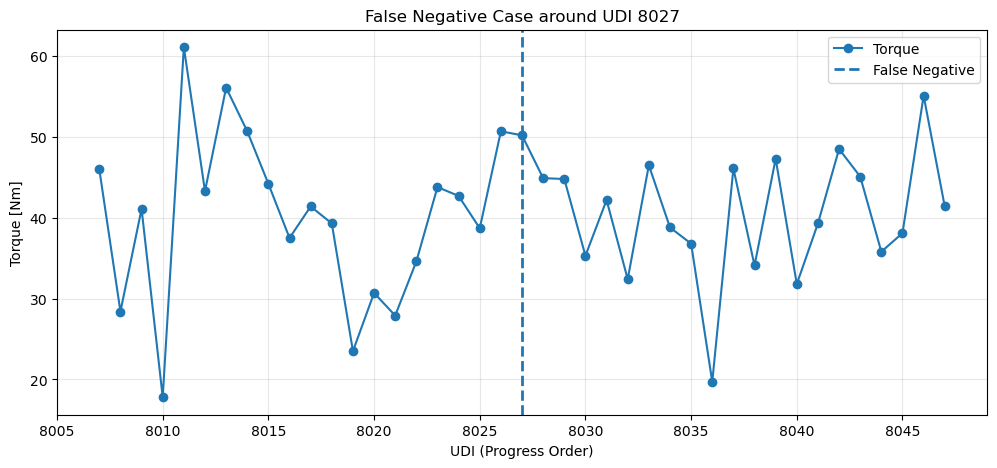

In [11]:
# -----------------------------
# 11. 고장 유형별 탐지 / 미탐 분석
# -----------------------------

failure_types = ["TWF", "HDF", "PWF", "OSF"]

summary = []

for f in failure_types:
    
    actual_cases = test_data[test_data[f] == 1]
    
    tp_count = len(
        actual_cases[
            actual_cases["Predicted"] == 1
        ]
    )
    
    fn_count = len(
        actual_cases[
            actual_cases["Predicted"] == 0
        ]
    )
    
    summary.append({
        "Failure Type": f,
        "Total": len(actual_cases),
        "Detected (TP)": tp_count,
        "Missed (FN)": fn_count
    })

failure_summary = pd.DataFrame(summary)

display(failure_summary)


# -----------------------------
# 미탐 사례 1건 시각화
# -----------------------------

# 첫 번째 FN 사례 선택
fn_example = fn_data.iloc[0]

fn_udi = fn_example["UDI"]

# 해당 지점 전후 구간
window_plot = 20

plot_data = data[
    (data["UDI"] >= fn_udi - window_plot) &
    (data["UDI"] <= fn_udi + window_plot)
]

plt.figure(figsize=(12, 5))

plt.plot(
    plot_data["UDI"],
    plot_data["Torque [Nm]"],
    marker="o",
    label="Torque"
)

plt.axvline(
    fn_udi,
    linestyle="--",
    linewidth=2,
    label="False Negative"
)

plt.xlabel("UDI (Progress Order)")
plt.ylabel("Torque [Nm]")
plt.title(f"False Negative Case around UDI {int(fn_udi)}")
plt.legend()
plt.grid(alpha=0.3)

plt.show()